# 摘要

本研究旨在運用 Python 進行信用貸款風險分析，透過探索性資料分析（EDA）、推論統計檢定與邏輯斯迴歸（Logistic Regression）模型，剖析 Kaggle 貸款資料集中的潛在違約因子。

分析結果證實，單憑性別、學歷等靜態「人口統計變數」難以精準預測遲繳機率，但此數據特性在實務上完美契合了金融業的「公平待客原則」。為進一步優化風險預防機制，本報告針對未來的智慧化企金評分卡提出具體優化藍圖，建議應擴充導入「動態信用行為」與「財務健康度」等硬指標，以建置具備高度可解釋性與準確度的風險預警防護網。

In [3]:
import pandas as pd
import numpy as np
path="C:/Users/user/Desktop/數據分析/日盛_數據分析/"
df=pd.read_csv(path+"Loan payments data.csv")

In [4]:
df

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female
...,...,...,...,...,...,...,...,...,...,...,...
495,xqd20160496,COLLECTION_PAIDOFF,1000,30,9/12/2016,10/11/2016,10/14/2016 19:08,3.0,28,High School or Below,male
496,xqd20160497,COLLECTION_PAIDOFF,1000,15,9/12/2016,9/26/2016,10/10/2016 20:02,14.0,26,High School or Below,male
497,xqd20160498,COLLECTION_PAIDOFF,800,15,9/12/2016,9/26/2016,9/29/2016 11:49,3.0,30,college,male
498,xqd20160499,COLLECTION_PAIDOFF,1000,30,9/12/2016,11/10/2016,11/11/2016 22:40,1.0,38,college,female


# <a id="data_dict"></a>資料欄位定義

In [ ]:
'''
-Loan_id：貸款編號（具唯一性，每筆貸款的專屬識別碼）。
-Loan_status：貸款狀態。此欄位為預測的目標變數，包含以下三種類別：
PAIDOFF：期限內正常還款。
COLLECTION_PAIDOFF：曾遲繳但最終已還清。
COLLECTION：遲繳且尚未還清。
-Principal：貸款本金（合約初始的借款總額）。
-terms：付款頻率。分為每週（7 天）、雙週（15 天）或每月（30 天）的還款計畫。
-Effective_date：貸款生效日（合約開始起算之日期）。
-Due_date：貸款到期日（因本專案為一次性還款計畫，每筆貸款僅對應單一到期日）。
-Paidoff_time：實際還款時間（包含確切的日期與時間）。
-Past_due_days：遲繳天數。
計算邏輯為：Paidoff_time（實際還款時間）減去 Due_date（到期日）。
資料檢核點：若客戶於到期日之前提前還款（Paidoff_time < Due_date），此欄位應為空值。
-Age, education, gender：客戶基本人口統計資訊（分別代表年齡、教育程度與性別）。
'''

# <a id="資料清理與探勘"></a>資料清理與探勘

## 日期清理：將日期格式轉換為台灣較熟悉的YYYY/MM/DD

In [9]:
# 1.把需要轉換的欄位裝進一個 list 裡，方便一次處理
df["paid_off_time_date"]=df["paid_off_time"].copy()
date_cols = ["effective_date", "due_date", "paid_off_time_date"]

# 2.將原始字串轉換為 pandas 的 Datetime 格式
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    
for col in date_cols:
    #df[col] = df[col].dt.strftime('%Y/%m/%d %H:%M')
    df[col] = pd.to_datetime(df[col].dt.strftime('%Y/%m/%d'))
# 查看轉換後的結果

display(df[["effective_date", "due_date", "paid_off_time_date","paid_off_time"]].head())
#paid_off_time_date用以計算，paid_off_time保留原始還款時間，以防萬一

,effective_date,due_date,paid_off_time_date,paid_off_time
0,2016-09-08,2016-10-07,2016-09-14,9/14/2016 19:31
1,2016-09-08,2016-10-07,2016-10-07,10/7/2016 9:00
2,2016-09-08,2016-10-07,2016-09-25,9/25/2016 16:58
3,2016-09-08,2016-09-22,2016-09-22,9/22/2016 20:00
4,2016-09-09,2016-10-08,2016-09-23,9/23/2016 21:36


## 新增變數date_diff，為起訖日的差異天數

In [11]:
df["date_diff"]=(df['due_date'] - df['effective_date']).dt.days+1#due_date和effective_date相減，和terms比較，能發現借款期間計算是【計頭計尾】
df["date_diff"]

0      30
1      30
2      30
3      15
4      30
       ..
495    30
496    15
497    15
498    60
499    30
Name: date_diff, Length: 500, dtype: int64

458筆的terms和date_diff相同，這些都是到期一次還清，中途沒有還款

In [13]:
df.loc[(df["terms"]==df["date_diff"]),["terms","date_diff","effective_date","due_date"]]

,terms,date_diff,effective_date,due_date
0,30,30,2016-09-08,2016-10-07
1,30,30,2016-09-08,2016-10-07
2,30,30,2016-09-08,2016-10-07
3,15,15,2016-09-08,2016-09-22
4,30,30,2016-09-09,2016-10-08
...,...,...,...,...
494,30,30,2016-09-12,2016-10-11
495,30,30,2016-09-12,2016-10-11
496,15,15,2016-09-12,2016-09-26
497,15,15,2016-09-12,2016-09-26


有42筆借款是期中開始還款，同時發現，date_diff為terms的倍數，例如60天到期，30天還款一次，這很合理。

In [15]:
df.loc[(df["terms"]!=df["date_diff"]),["Loan_ID","terms","date_diff","effective_date","due_date"]]

,Loan_ID,terms,date_diff,effective_date,due_date
11,xqd20160012,15,30,2016-09-10,2016-10-09
42,xqd20160043,7,14,2016-09-11,2016-09-24
85,xqd20160086,30,60,2016-09-11,2016-11-09
109,xqd20160110,7,14,2016-09-11,2016-09-24
111,xqd20160112,30,60,2016-09-11,2016-11-09
122,xqd20160123,15,45,2016-09-11,2016-10-25
137,xqd20160138,15,45,2016-09-11,2016-10-25
146,xqd20160147,30,60,2016-09-11,2016-11-09
150,xqd20160151,15,45,2016-09-12,2016-10-26
165,xqd20160166,30,60,2016-09-12,2016-11-10


## 檢查空值

In [17]:
df.isnull().any()

Loan_ID               False
loan_status           False
Principal             False
terms                 False
effective_date        False
due_date              False
paid_off_time          True
past_due_days          True
age                   False
education             False
Gender                False
paid_off_time_date     True
date_diff             False
dtype: bool

## paid_off_time_date為Nan的情況：遲繳了，因此past_due_days一定有值

In [19]:
df.loc[df["paid_off_time_date"].isna()]

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,paid_off_time_date,date_diff
300,xqd20160301,COLLECTION,1000,15,2016-09-09,2016-09-23,NaN,76.0,29,college,male,NaT,15
301,xqd20160302,COLLECTION,1000,30,2016-09-09,2016-10-08,NaN,61.0,37,High School or Below,male,NaT,30
302,xqd20160303,COLLECTION,1000,30,2016-09-09,2016-10-08,NaN,61.0,33,High School or Below,male,NaT,30
303,xqd20160304,COLLECTION,800,15,2016-09-09,2016-09-23,NaN,76.0,27,college,male,NaT,15
304,xqd20160305,COLLECTION,800,15,2016-09-09,2016-09-23,NaN,76.0,24,Bechalor,male,NaT,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,xqd20160396,COLLECTION,1000,30,2016-09-11,2016-10-10,NaN,59.0,25,High School or Below,male,NaT,30
396,xqd20160397,COLLECTION,1000,30,2016-09-12,2016-10-11,NaN,58.0,33,High School or Below,male,NaT,30
397,xqd20160398,COLLECTION,800,15,2016-09-12,2016-09-26,NaN,73.0,39,college,male,NaT,15
398,xqd20160399,COLLECTION,1000,30,2016-09-12,2016-11-10,NaN,28.0,28,college,male,NaT,60


檢查paid_off_time_date為Nan的情況下，past_due_days是否一定有值：是的，此情況不存在空值

In [21]:
df.loc[df["paid_off_time_date"].isna(),["past_due_days"]].isna().any()

past_due_days    False
dtype: bool

可以觀察到 列300與301 due_date與past_due_days都是相差15天，可以反推此張表是站在哪一天的視角去統計的

In [23]:
test=df.loc[df["paid_off_time_date"].isna(),["paid_off_time_date","due_date","past_due_days"]]
test

,paid_off_time_date,due_date,past_due_days
300,NaT,2016-09-23,76.0
301,NaT,2016-10-08,61.0
302,NaT,2016-10-08,61.0
303,NaT,2016-09-23,76.0
304,NaT,2016-09-23,76.0
...,...,...,...
395,NaT,2016-10-10,59.0
396,NaT,2016-10-11,58.0
397,NaT,2016-09-26,73.0
398,NaT,2016-11-10,28.0


由於遲繳一天後才會被計算，因此日期直接加上去反推就好

In [25]:
test["new_date"] = test["due_date"] + pd.to_timedelta(test["past_due_days"], unit='D')
test["new_date"]

300   2016-12-08
301   2016-12-08
302   2016-12-08
303   2016-12-08
304   2016-12-08
         ...    
395   2016-12-08
396   2016-12-08
397   2016-12-08
398   2016-12-08
399   2016-12-08
Name: new_date, Length: 100, dtype: datetime64[ns]

檢查是否都是 2016-12-08：是的，代表這張表是在2016-12-08編制的

In [27]:
np.unique(test["new_date"])

array(['2016-12-08T00:00:00.000000000'], dtype='datetime64[ns]')

## past_due_days為Nan的情況：在期限內還款(當paid_off_time_date 小於等於 due_date)且loan_status應為PAIDOFF

In [29]:
test=df.loc[df["past_due_days"].isna()]
test#有300筆資料沒有遲繳

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,paid_off_time_date,date_diff
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/14/2016 19:31,NaN,45,High School or Below,male,2016-09-14,30
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,10/7/2016 9:00,NaN,50,Bechalor,female,2016-10-07,30
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/25/2016 16:58,NaN,33,Bechalor,female,2016-09-25,30
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,9/22/2016 20:00,NaN,27,college,male,2016-09-22,15
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,9/23/2016 21:36,NaN,28,college,female,2016-09-23,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,xqd20160296,PAIDOFF,1000,30,2016-09-14,2016-10-13,10/13/2016 13:00,NaN,30,college,female,2016-10-13,30
296,xqd20160297,PAIDOFF,800,15,2016-09-14,2016-09-28,9/21/2016 4:42,NaN,27,college,male,2016-09-21,15
297,xqd20160298,PAIDOFF,1000,30,2016-09-14,2016-10-13,10/13/2016 9:00,NaN,29,High School or Below,male,2016-10-13,30
298,xqd20160299,PAIDOFF,1000,30,2016-09-14,2016-10-13,10/13/2016 9:00,NaN,40,High School or Below,male,2016-10-13,30


檢查300筆都被標註為PaidOff

In [31]:
np.unique(test["loan_status"])

array(['PAIDOFF'], dtype=object)

有一筆不符合日期規則，但只有差1天，並且在隔天11:03還款，猜測也許是實務上隔天中午前還不算違約

In [33]:
test.loc[df["paid_off_time_date"]>df["due_date"]]

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,paid_off_time_date,date_diff
270,xqd20160271,PAIDOFF,1000,30,2016-09-14,2016-10-13,10/14/2016 11:03,NaN,29,High School or Below,male,2016-10-14,30


為了驗證猜想，尋找past_due_day=1只遲繳一天的資料
發現其中有包含上午11點附近的時間，最早是11:14還款就被記錄遲繳，但是11:03還款就沒有被記錄遲繳，認為不合理，懷疑xqd20160271交易誤植

In [35]:
df.loc[df["past_due_days"]==1,["due_date","paid_off_time","past_due_days"]]

,due_date,paid_off_time,past_due_days
410,2016-10-09,10/10/2016 15:18,1.0
413,2016-09-25,9/26/2016 11:35,1.0
416,2016-10-10,10/11/2016 12:45,1.0
424,2016-11-09,11/10/2016 22:58,1.0
426,2016-10-10,10/11/2016 16:44,1.0
429,2016-10-10,10/11/2016 17:22,1.0
434,2016-10-10,10/11/2016 11:33,1.0
435,2016-10-10,10/11/2016 16:27,1.0
437,2016-10-10,10/11/2016 16:13,1.0
442,2016-10-10,10/11/2016 11:48,1.0


## 生成虛擬變數

是否遲繳

In [38]:
df["delay"]=(~df["past_due_days"].isna())+0 
df[["delay"]]

,delay
0,0
1,0
2,0
3,0
4,0
...,...
495,1
496,1
497,1
498,1


性別：男1女0 手動製作虛擬變數

In [40]:
df["Male"]=(df["Gender"]=="male")+0
df["Female"]=(df["Gender"]=="female")+0
df[["Male","Female","Gender"]]

,Male,Female,Gender
0,1,0,male
1,0,1,female
2,0,1,female
3,1,0,male
4,0,1,female
...,...,...,...
495,1,0,male
496,1,0,male
497,1,0,male
498,0,1,female


教育程度，較多，使用get_dummies再進行合併

In [42]:
education_dummies=pd.get_dummies(df["education"])+0
education_dummies

,Bechalor,High School or Below,Master or Above,college
0,0,1,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
495,0,1,0,0
496,0,1,0,0
497,0,0,0,1
498,0,0,0,1


In [43]:
df = pd.concat([df, education_dummies], axis=1)

In [44]:
df

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,paid_off_time_date,date_diff,delay,Male,Female,Bechalor,High School or Below,Master or Above,college
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/14/2016 19:31,NaN,45,High School or Below,male,2016-09-14,30,0,1,0,0,1,0,0
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,10/7/2016 9:00,NaN,50,Bechalor,female,2016-10-07,30,0,0,1,1,0,0,0
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/25/2016 16:58,NaN,33,Bechalor,female,2016-09-25,30,0,0,1,1,0,0,0
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,9/22/2016 20:00,NaN,27,college,male,2016-09-22,15,0,1,0,0,0,0,1
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,9/23/2016 21:36,NaN,28,college,female,2016-09-23,30,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,xqd20160496,COLLECTION_PAIDOFF,1000,30,2016-09-12,2016-10-11,10/14/2016 19:08,3.0,28,High School or Below,male,2016-10-14,30,1,1,0,0,1,0,0
496,xqd20160497,COLLECTION_PAIDOFF,1000,15,2016-09-12,2016-09-26,10/10/2016 20:02,14.0,26,High School or Below,male,2016-10-10,15,1,1,0,0,1,0,0
497,xqd20160498,COLLECTION_PAIDOFF,800,15,2016-09-12,2016-09-26,9/29/2016 11:49,3.0,30,college,male,2016-09-29,15,1,1,0,0,0,0,1
498,xqd20160499,COLLECTION_PAIDOFF,1000,30,2016-09-12,2016-11-10,11/11/2016 22:40,1.0,38,college,female,2016-11-11,60,1,0,1,0,0,0,1


# <a id="descriptive"></a> 敘述統計

In [46]:
df

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,paid_off_time_date,date_diff,delay,Male,Female,Bechalor,High School or Below,Master or Above,college
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/14/2016 19:31,NaN,45,High School or Below,male,2016-09-14,30,0,1,0,0,1,0,0
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,10/7/2016 9:00,NaN,50,Bechalor,female,2016-10-07,30,0,0,1,1,0,0,0
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,9/25/2016 16:58,NaN,33,Bechalor,female,2016-09-25,30,0,0,1,1,0,0,0
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,9/22/2016 20:00,NaN,27,college,male,2016-09-22,15,0,1,0,0,0,0,1
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,9/23/2016 21:36,NaN,28,college,female,2016-09-23,30,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,xqd20160496,COLLECTION_PAIDOFF,1000,30,2016-09-12,2016-10-11,10/14/2016 19:08,3.0,28,High School or Below,male,2016-10-14,30,1,1,0,0,1,0,0
496,xqd20160497,COLLECTION_PAIDOFF,1000,15,2016-09-12,2016-09-26,10/10/2016 20:02,14.0,26,High School or Below,male,2016-10-10,15,1,1,0,0,1,0,0
497,xqd20160498,COLLECTION_PAIDOFF,800,15,2016-09-12,2016-09-26,9/29/2016 11:49,3.0,30,college,male,2016-09-29,15,1,1,0,0,0,0,1
498,xqd20160499,COLLECTION_PAIDOFF,1000,30,2016-09-12,2016-11-10,11/11/2016 22:40,1.0,38,college,female,2016-11-11,60,1,0,1,0,0,0,1


## 針對貸款

In [48]:
desc = df[["Principal", "terms", "delay"]].describe().round(2)
summary_msg = (
    f"總共有 {int(desc.loc['count', 'Principal'])} 筆貸款資料。\n"
    f"貸款金額 (Principal) 從最小 {desc.loc['min', 'Principal']:,.0f} 到最大 {desc.loc['max', 'Principal']:,.0f}，平均數為 {desc.loc['mean', 'Principal']:,.2f}；\n"
    f"付款頻率 (terms) 介於 {desc.loc['min', 'terms']} 至 {desc.loc['max', 'terms']} 天，平均約為 {desc.loc['mean', 'terms']} 天；\n"
    f"此外，遲繳 (delay) 的平均值為 {desc.loc['mean', 'delay']}，代表整體遲繳率約為 {desc.loc['mean', 'delay']*100:.0f}%。"
)

# 3. 印出結果
print(summary_msg)

總共有 500 筆貸款資料。
貸款金額 (Principal) 從最小 300 到最大 1,000，平均數為 943.20；
付款頻率 (terms) 介於 7.0 至 30.0 天，平均約為 22.82 天；
此外，遲繳 (delay) 的平均值為 0.4，代表整體遲繳率約為 40%。


## 針對貸款人

In [50]:
demo_cols = ["age", "Male", "Female", "Bechalor", "High School or Below", "Master or Above", "college"]
desc_demo = df[demo_cols].describe().round(2)

profile_msg = (
    f"【貸款人輪廓分析】\n"
    f"本資料集的貸款人年齡 (age) 分布從最小 {desc_demo.loc['min', 'age']:.0f} 歲至最大 {desc_demo.loc['max', 'age']:.0f} 歲，平均年齡約為 {desc_demo.loc['mean', 'age']:.0f} 歲。\n"
    f"在性別分布上，男性貸款人佔比為 {desc_demo.loc['mean', 'Male']*100:.0f}%，女性則佔 {desc_demo.loc['mean', 'Female']*100:.0f}%。\n"
    f"教育程度方面，以整體佔比來看：高中及以下 (High School or Below) 佔 {desc_demo.loc['mean', 'High School or Below']*100:.0f}%，"
    f"專科/大學 (college) 佔 {desc_demo.loc['mean', 'college']*100:.0f}%，"
    f"學士 (Bechalor) 佔 {desc_demo.loc['mean', 'Bechalor']*100:.0f}%，"
    f"碩士及以上 (Master or Above) 族群則佔 {desc_demo.loc['mean', 'Master or Above']*100:.0f}%。"
)

print(profile_msg)

【貸款人輪廓分析】
本資料集的貸款人年齡 (age) 分布從最小 18 歲至最大 51 歲，平均年齡約為 31 歲。
在性別分布上，男性貸款人佔比為 85%，女性則佔 15%。
教育程度方面，以整體佔比來看：高中及以下 (High School or Below) 佔 42%，專科/大學 (college) 佔 44%，學士 (Bechalor) 佔 13%，碩士及以上 (Master or Above) 族群則佔 1%。


## 針對遲繳客群

In [52]:
import pandas as pd
from scipy.stats import ttest_ind

# 分割客群 (1 為遲繳，0 為無遲繳)
delay_df = df[df["delay"] == 1]
nodelay_df = df[df["delay"] == 0]

# 將所有要分析的變數放進 list (包含連續變數 age 與類別的虛擬變數)
analyze_cols = ["age", "Male", "Female", "High School or Below", "college", "Bechalor", "Master or Above"]

# 建立一個空的清單來存放統計結果
rows = []

for col in analyze_cols:
    # 1. 計算各群體的平均值
    total_mean = df[col].mean()
    delay_mean = delay_df[col].mean()
    nodelay_mean = nodelay_df[col].mean()
    
    # 2. 執行獨立樣本 T 檢定 (Welch's t-test, 設定 equal_var=False 較符合實務)
    t_stat, p_val = ttest_ind(delay_df[col].dropna(), nodelay_df[col].dropna(), equal_var=False)
    
    # 3. 數值轉換：如果是虛擬變數 (0/1)，我們將平均數乘上 100 轉為「百分比」數值；age 則維持不變
    multiplier = 1 if col == "age" else 100
    
    rows.append({
        "變數 (Feature)": col,
        "1. 全部": total_mean * multiplier,
        "2. 遲繳客群": delay_mean * multiplier,
        "3. 無遲繳客群": nodelay_mean * multiplier,
        "4. T檢定 (P-value)": p_val
    })

# 將結果轉換為 DataFrame
stat_table = pd.DataFrame(rows).set_index("變數 (Feature)")

# --- 顯示統計表 ---
# 利用 style.format 將 P-value 鎖定為 4 位小數，其他鎖定為 2 位小數
styled_table = stat_table.style.format({
    "1. 全部": "{:.2f}",
    "2. 遲繳客群": "{:.2f}",
    "3. 無遲繳客群": "{:.2f}",
    "4. T檢定 (P-value)": "{:.4f}"
})
display(styled_table)

# --- 生成 f-string 洞察摘要 ---
# 判斷性別差異是否顯著 (P-value < 0.05 代表顯著)
gender_sig_text = "達顯著差異" if stat_table.loc['Male', '4. T檢定 (P-value)'] < 0.05 else "未達顯著差異"

delay_summary_msg = (
    f"【遲繳與未遲繳客群差異 T 檢定摘要】\n"
    f"年齡方面：全部客戶平均 {stat_table.loc['age', '1. 全部']:.0f} 歲，"
    f"遲繳客群平均為 {stat_table.loc['age', '2. 遲繳客群']:.0f} 歲，未遲繳為 {stat_table.loc['age', '3. 無遲繳客群']:.0f} 歲 "
    f"(P-value = {stat_table.loc['age', '4. T檢定 (P-value)']:.4f})。\n"
    f"性別方面：遲繳客群中男性佔 {stat_table.loc['Male', '2. 遲繳客群']:.0f}%，未遲繳客群中男性佔 {stat_table.loc['Male', '3. 無遲繳客群']:.0f}%，"
    f"兩者在統計上{gender_sig_text}。\n"
    f"教育程度方面：遲繳客群中『高中及以下』佔 {stat_table.loc['High School or Below', '2. 遲繳客群']:.0f}%，"
    f"對比未遲繳客群的 {stat_table.loc['High School or Below', '3. 無遲繳客群']:.0f}%，"
    f"可藉由 P-value ({stat_table.loc['High School or Below', '4. T檢定 (P-value)']:.4f}) 判斷此學歷對遲繳機率之影響是否顯著。"
)

print("-" * 50) # 畫一條分隔線
print(delay_summary_msg)

,1. 全部,2. 遲繳客群,3. 無遲繳客群,4. T檢定 (P-value)
變數 (Feature),,,,
age,31.12,30.98,31.21,0.6740
Male,84.60,88.00,82.33,0.0762
Female,15.40,12.00,17.67,0.0762
High School or Below,41.80,43.00,41.00,0.6582
college,44.00,43.50,44.33,0.8544
Bechalor,13.40,13.00,13.67,0.8300
Master or Above,0.80,0.50,1.00,0.5122


--------------------------------------------------
【遲繳與未遲繳客群差異 T 檢定摘要】
年齡方面：全部客戶平均 31 歲，遲繳客群平均為 31 歲，未遲繳為 31 歲 (P-value = 0.6740)。
性別方面：遲繳客群中男性佔 88%，未遲繳客群中男性佔 82%，兩者在統計上未達顯著差異。
教育程度方面：遲繳客群中『高中及以下』佔 43%，對比未遲繳客群的 41%，可藉由 P-value (0.6582) 判斷此學歷對遲繳機率之影響是否顯著。


若以P-value小於0.05為顯著依據，則遲繳與否在年齡、性別、以及學歷的差異在統計上不顯著，這可能是資料本身的特性導致，另一個角度，代表企業並沒有因性別或學歷而產生放貸偏見，符合公平待客原則。資料缺乏差異性，則後續的迴歸分析也可能不顯著。

# 邏輯斯迴歸分析

In [55]:
import statsmodels.api as sm
import pandas as pd

# 1. 定義特徵變數 X 與目標變數 Y
features = ['age', 'Male', 'High School or Below', 'college', 'Bechalor', 'Principal', 'terms']

# 為了確保資料型態安全，強制將 X 轉為 float (有時候布林值或整數會造成 statsmodels 報錯)
X = df[features].astype(float)
y = df['delay'].astype(int)

# 2. 加上常數項 (Intercept)
# 這在 statsmodels 中是必要的步驟，代表模型的截距
X = sm.add_constant(X)

# 3. 建立 Logistic Regression (Logit) 模型並訓練
# 加上 disp=False 可以隱藏訓練過程的文字輸出，讓畫面更乾淨
logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False)

# 4. 印出統計摘要報告
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                  delay   No. Observations:                  500
Model:                          Logit   Df Residuals:                      492
Method:                           MLE   Df Model:                            7
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.01445
Time:                        15:34:48   Log-Likelihood:                -331.64
converged:                       True   LL-Null:                       -336.51
Covariance Type:            nonrobust   LLR p-value:                    0.2049
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.2447      1.508     -1.488      0.137      -5.201       0.712
age                     -0.0012      0.016     -0.079      0.937      -0.032       0.029
Male        

從邏輯斯迴歸的結果來看，不管是整體模型還是單一變數，P-value 都大於 0.05。這告訴我們兩件重要的觀點：

第一，我們沒辦法單看客戶的性別、年齡或學歷就判斷該客戶會不會遲繳。但這在實務上其實是好事，因為這完全符合『公平待客原則』，代表我們的授信標準不會有性別或學歷歧視。

第二，要想提升預測力，我們必須引入『財務與行為變數』。 目前的資料為【靜態】資料，而且沒有 Customer ID 可以追蹤該客戶的過去。如果是在日盛台駿的真實業務場景中，我會建議模型必須納入兩塊資料：一是客戶過往的聯徵或內部貸款紀錄，用歷史信用來預測未來行為；二是引入年收入、車貸房貸餘額（算負債比），或是婚姻狀況，這種能真正反映『財務健康度』的硬指標，才能建置出真正有用的企金評分卡。

# 預測分析

In [58]:
# 提取模型的所有係數 (回傳格式為 pandas Series)
coef = result.params

# 1. 初始化方程式字串，先放入常數項 (Intercept)
# 在 statsmodels 中，常數項的名稱預設為 'const'
equation = f"y = {coef['const']:.4f}"

# 2. 動態迭代其他特徵變數
for feature in result.model.exog_names:
    if feature != 'const':
        val = coef[feature]
        # 自動判斷正負號，讓排版更漂亮 (避免出現 + - 疊在一起)
        sign = "+" if val >= 0 else "-"
        
        # 如果特徵名稱包含空白 (例如 High School or Below)，幫它加上引號或括號以利閱讀
        feature_name = f"'{feature}'" if " " in feature else feature
        
        # 將變數拼接到方程式後方，使用 abs() 確保數值本身沒有負號
        equation += f" {sign} {abs(val):.4f} * {feature_name}"

# 3. 印出完整方程式
print("【邏輯斯迴歸方程式】")
print(equation)

【邏輯斯迴歸方程式】
y = -2.2447 - 0.0012 * age + 0.4560 * Male + 0.2636 * 'High School or Below' + 0.2241 * college + 0.2369 * Bechalor + 0.0008 * Principal + 0.0217 * terms


所有資料的預測遲繳機率：
         Loan_ID  predict_prob
0    xqd20166231      0.465398
1    xqd20168902      0.348071
2    xqd20160003      0.352815
3    xqd20160004      0.382015
4    xqd20160005      0.351299
..           ...           ...
495  xqd20160496      0.470586
496  xqd20160497      0.391680
497  xqd20160498      0.344561
498  xqd20160499      0.348511
499  xqd20160500      0.470586

[500 rows x 2 columns]


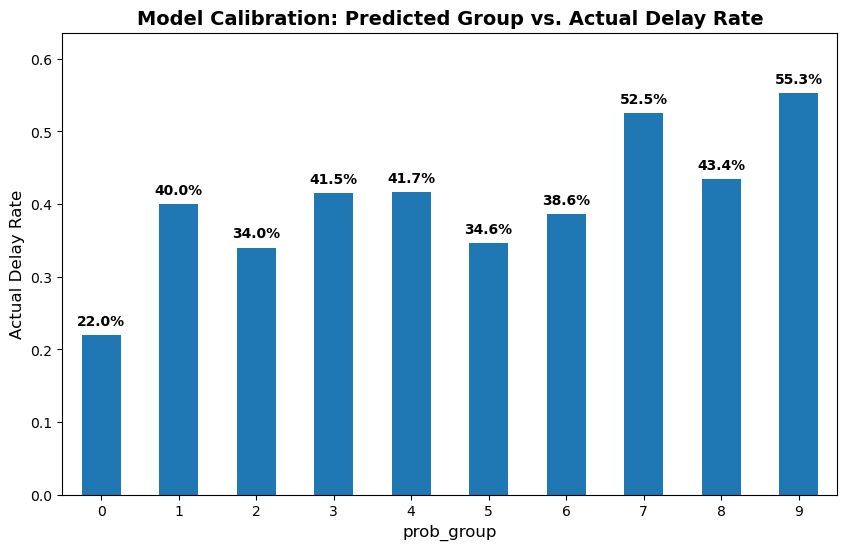

In [67]:
import matplotlib.pyplot as plt
# 使用訓練好的模型預測所有人的遲繳機率
# 注意：預測用的 X 必須包含常數項 (Intercept)
df['predict_prob'] = result.predict(X)
# 看看前 5 筆預測出來的機率
print("所有資料的預測遲繳機率：")
print(df[['Loan_ID', 'predict_prob']])
# 將預測機率由低到高分成 10 個等分 (Deciles)
df['prob_group'] = pd.qcut(df['predict_prob'], q=10, labels=False, duplicates='drop')
# 計算每個機率組別的「實際遲繳率」
calibration_analysis = df.groupby('prob_group')['delay'].mean()
# 設定畫布大小，讓圖表更寬敞舒適
plt.figure(figsize=(10, 6))

# 畫出長條圖，並將回傳的 axes 物件存入變數 ax
ax = calibration_analysis.plot(kind='bar')

# 透過迴圈讀取圖表中的每一個長條 (patches)
for p in ax.patches:
    # 取得長條的高度 (即 actual delay rate)
    height = p.get_height()
    
    # 在長條的正上方加上百分比標籤
    # {height:.1%} 會自動將小數轉換為百分比，並保留一位小數 (例如 0.412 變成 41.2%)
    ax.annotate(f'{height:.1%}',
                xy=(p.get_x() + p.get_width() / 2, height), # 標籤的 X, Y 座標位置 (長條正中間)
                xytext=(0, 5), # 讓文字稍微往上偏移 5 個像素，才不會和長條黏在一起
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 設定標題與標籤
plt.title("Model Calibration: Predicted Group vs. Actual Delay Rate", fontsize=14, fontweight='bold')
plt.ylabel("Actual Delay Rate", fontsize=12)
plt.xlabel("prob_group", fontsize=12)

# 將 X 軸的數字轉正，比較容易閱讀
plt.xticks(rotation=0)

# 為了避免最上面的標籤被圖表邊緣裁切到，可以稍微拉高 Y 軸的上限
plt.ylim(0, calibration_analysis.max() * 1.15) 

plt.show()

邏輯斯迴歸分析與預測流程

1.得到方程式： 也就是「模型訓練」，找出各個變數與遲繳之間的數學權重。

2.計算預測遲繳機率： 把500筆實際的資料帶入訓練好的模型中，計算「違約機率 (PD, Probability of Default)」，透過 Sigmoid 函數將方程式的結果壓縮成 0~1 的機率值，也就是預測的遲繳機率。

3.依機率高低分成 10 組： 這稱為「十分位分群」，目的是把連續的機率切分成不同的風險等級 (Risk Grades)，最左邊的組別違約機率最低，最右邊的組別違約機率最高。

4.觀察實際遲繳率是否遞增： 一個完美的模型，這 10 組的柱狀圖會呈現漂亮的階梯狀向右上攀升，代表預測遲繳機率高的資料，實際遲繳機率也高；但目前的圖表中間高低起伏，就印證了我們前面說的「缺乏行為變數，導致模型預測力（尤其是對中間客群）不穩定」。

5.這個模型的insight：最低風險組 (group 0)： 實際遲繳率約落在 22%，是全場最低。最高風險組 (group 9)： 實際遲繳率超過 50%（約 55%），是全場最高。

這代表這個模型雖然粗糙，但它已經具備了「抓出極端好客與極端壞客」的能力。如果公司現在立刻需要一個政策，我們可以設定：「落入 group 9 的人直接拒貸，落入 group 0 的人給予利率優惠」，這依然能為公司省下呆帳成本。以這個模型而言，如果一個客戶的資料被判斷落在group 0，則有約80%的機率他不會遲繳。若模型完善後，可根據客戶落入不同的組別，來判斷放貸的利率、本金、期間等等條件。

# 實務應用

實務應用上，假設模型已經訓練好了，核貸人員可以輸入此筆貸款的資訊，系統判斷逾期機率並給出建議

In [71]:
import pandas as pd
import numpy as np

# --- 1. 取得剛剛的 10 等分邊界值 (Bins) ---
_, bins = pd.qcut(df['predict_prob'], q=10, labels=False, duplicates='drop', retbins=True)
bins[0] = 0.0
bins[-1] = 1.0

# --- 2. 建立預測評估函數 ---
def evaluate_loan_risk(age=30, gender='Male', education='college', principal=1000, terms=15):
    """
    輸入客戶條件，自動輸出風險分群與核貸建議。
    gender 可選: 'Male', 'Female'
    education 可選: 'High School or Below', 'college', 'Bechalor', 'Master or Above'
    terms 可選: 7, 15, 30
    """
    
    # 將輸入值轉換為虛擬變數
    is_male = 1 if gender == 'Male' else 0
    is_hs = 1 if education == 'High School or Below' else 0
    is_col = 1 if education == 'college' else 0
    is_bac = 1 if education == 'Bechalor' else 0
    
    # 建立新資料
    new_data = pd.DataFrame({
        'const': [1.0],
        'age': [age],
        'Male': [is_male],
        'High School or Below': [is_hs],
        'college': [is_col],
        'Bechalor': [is_bac],
        'Principal': [principal],
        'terms': [terms]
    })
    
    # 進行預測
    pred_prob = result.predict(new_data).iloc[0]
    
    # 計算組別與歷史違約率
    group_idx = np.digitize(pred_prob, bins) - 1
    group_idx = max(0, min(group_idx, 9))
    group_actual_rate = calibration_analysis.loc[group_idx] * 100
    
    # --- 印出美觀的系統結果 ---
    print("="*50)
    print("📊 【貸放風險輔助評估系統 - 判定結果】")
    print(f"👤 客戶條件：{age}歲 | {gender} | {education} | 借款 {principal} | 期限 {terms}天")
    print("-" * 50)
    print(f"🔹 系統預測此筆貸款違約機率為： {pred_prob*100:.2f}%")
    print(f"🔹 根據風險屬性，該筆案件被歸類於： 第 {group_idx} 組 (風險等級 0-9，數字越大風險越高)")
    print(f"🔹 【歷史參考】此風險組別過往的實際遲繳率約為： {group_actual_rate:.2f}%")
    print("-" * 50)
    
    # 業務邏輯判斷建議
    if group_idx >= 7:
        print("⚠️ 系統警示：此案件屬於高風險客群，建議婉拒或要求提供財力保證人。")
    elif group_idx <= 2:
        print("✅ 系統提示：此案件屬於優質客群，建議快速核貸或給予利率優惠。")
    else:
        print("ℹ️ 系統提示：此案件屬於一般風險，建議依常規授信流程審查。")
    print("="*50)

# --- 3. 使用者介面 ---
def terminal_loan_system():
    print("="*50)
    print("🏦 歡迎登入：貸放風險輔助評估系統 (CLI終端機版)")
    print("="*50)
    print("請依序輸入客戶條件，系統將即時分析違約風險。\n")
    
    try:
        # 使用 input() 讓使用者一問一答
        age = int(input("👤 [1/5] 請輸入客戶年齡 (數字，例如 30): "))
        
        print("\n性別選項：1. Male  2. Female")
        g_choice = input("🚻 [2/5] 請選擇性別 (輸入 1 或 2): ")
        gender = 'Male' if g_choice == '1' else 'Female'
        
        print("\n學歷選項：1. High School or Below  2. college  3. Bechalor  4. Master or Above")
        e_choice = input("🎓 [3/5] 請選擇教育程度 (輸入 1~4): ")
        edu_dict = {'1': 'High School or Below', '2': 'college', '3': 'Bechalor', '4': 'Master or Above'}
        education = edu_dict.get(e_choice, 'college') # 預設 college
        
        principal = int(input("\n💰 [4/5] 請輸入貸款本金 (數字，例如 1000): "))
        
        terms = int(input("🗓️ [5/5] 請輸入還款期數 (7 / 15 / 30): "))
        
        print("\n⏳ 系統運算中，請稍候...\n")
        
        # 呼叫我們剛剛寫好的預測函數
        evaluate_loan_risk(age=age, gender=gender, education=education, principal=principal, terms=terms)
        
    except ValueError:
        print("\n❌ 錯誤：請輸入正確的數字格式！請重新執行。")

# 啟動系統
terminal_loan_system()


🏦 歡迎登入：貸放風險輔助評估系統 (CLI終端機版)
請依序輸入客戶條件，系統將即時分析違約風險。



👤 [1/5] 請輸入客戶年齡 (數字，例如 30):  30



性別選項：1. Male  2. Female


🚻 [2/5] 請選擇性別 (輸入 1 或 2):  2



學歷選項：1. High School or Below  2. college  3. Bechalor  4. Master or Above


🎓 [3/5] 請選擇教育程度 (輸入 1~4):  4

💰 [4/5] 請輸入貸款本金 (數字，例如 1000):  1000
🗓️ [5/5] 請輸入還款期數 (7 / 15 / 30):  7



⏳ 系統運算中，請稍候...

📊 【貸放風險輔助評估系統 - 判定結果】
👤 客戶條件：30歲 | Female | Master or Above | 借款 1000 | 期限 7天
--------------------------------------------------
🔹 系統預測此筆貸款違約機率為： 20.78%
🔹 根據風險屬性，該筆案件被歸類於： 第 0 組 (風險等級 0-9，數字越大風險越高)
🔹 【歷史參考】此風險組別過往的實際遲繳率約為： 22.00%
--------------------------------------------------
✅ 系統提示：此案件屬於優質客群，建議快速核貸或給予利率優惠。


# 結論

本專案以 Kaggle Loan Data 為基礎，運用 Python 進行端到端的資料分析（涵蓋資料清理、探索性分析、推論統計、邏輯斯迴歸與預測機率校準），旨在挖掘影響客戶遲繳的潛在風險因子，進而優化貸前審查（Pre-loan Assessment）機制，達成風險預防的目標。綜合分析後得出以下五項核心結論：

1. 資料治理與業務邏輯對齊
在資料前處理階段，發現部分資料的逾期天數計算邏輯可能與常規遲繳定義不完全吻合。若此情況發生於真實業務場景，數據分析團隊必須主動跨部門與業務單位、IT 端確認底層系統的「計息與違約天數起算慣例（Day Count Convention）」，確保資料一致性後，方能進行後續的特徵工程。

2. 人口變數之預測侷限與合規價值
經獨立樣本 T 檢定分析，客群的「性別、學歷、年齡」在遲繳傾向上並無統計顯著差異。這代表單憑靜態人口特徵無法有效切分好壞客群；但從合規（Compliance）角度來看，這項發現完美契合了「公平待客原則（Fair Lending）」，確保了授信政策不會因性別或學歷而產生放貸歧視。

3. 統計解釋力不足之業務警訊
邏輯斯迴歸（Logistic Regression）結果顯示，整體模型 LLR p-value 大於 0.05 且各變數皆不顯著，進一步證實了靜態人口變數對逾期行為缺乏實質的解釋力。這強烈暗示了目前蒐集的特徵維度過於單薄，無法真實反映客戶潛在的信用風險。

4. 極端風險辨識仍具初步業務價值
儘管特徵不顯著，但將模型預測之違約機率（PD）進行十分位分群（Decile Binning）校準後發現：模型在「極端值」的捕捉上仍具成效（最低預測風險組實際違約率為 22%，而最高風險組則高達 55%）。這意味著此模型在現階段仍有業務落地價值，可作為制定「黑名單直接拒貸」或「優質客群快速核貸」等極端授信政策的輔助參考。

5. 智慧化評分卡優化建議
針對模型中間客群預測波動大的痛點，未來在建置或優化企金/消金評分卡時，強烈建議擴充兩大維度的指標：

縱向信用歷史： 引入 Customer ID 串接內部或聯徵紀錄，追蹤客戶過往的貸款表現與近期查詢次數等動態行為。

橫向財務健康度： 引入年收入、車房貸負債收支比、婚姻狀況等指標。
透過導入上述行為與財務變數，方能真正完善風險預警機制，大幅提升 AI 數據模型的預測力與商業影響力。